# Benchmarking dependency measures for marker-gene identification in multi-modal single-cell data

**PBMC CITE-seq (Hao et al. 2021) — a 2×2 decomposition of dependency measures.**
**Granularity: L1 (8 major lineages).**

|            | Marginal                | Conditional                       |
|------------|-------------------------|-----------------------------------|
| **Linear**    | Spearman correlation    | Partial correlation (shrinkage)   |
| **Nonlinear** | Mutual information (KSG) | Integrated Gradients on an MLP     |

We ask whether *nonlinearity* and *multivariate context* change which genes are
identified as cell-type markers, and which axis matters more. Every method sees
**RNA only**; the surface-protein (ADT) modality is used solely to define a
cross-modal, protein-derived ground-truth driver set $D_c$ per cell type. Recovery
of $D_c$ is scored with the parameter-free $\mathrm{AUC_{rel}}$ metric.

All heavy logic lives in the importable `src/` package; this notebook only
orchestrates and narrates. See `README.md` for the full list of design decisions.

In [1]:
import os, sys
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # avoid OpenMP runtime clash
if sys.platform == "win32":   # jupyter launches the kernel unactivated; expose env DLLs
    for _sub in ("Library/bin", "Library/mingw-w64/bin", "Library/usr/bin",
                 "Scripts", "bin", "DLLs"):
        _p = os.path.join(sys.prefix, _sub)
        if os.path.isdir(_p):
            os.add_dll_directory(_p)
            os.environ["PATH"] = _p + os.pathsep + os.environ.get("PATH", "")
import torch  # noqa: F401  import torch FIRST so its MKL/OpenMP DLLs win over the
              # conda stack's (otherwise torch's shm.dll fails with WinError 127)
sys.path.insert(0, "..")
import numpy as np, pandas as pd
from types import SimpleNamespace
from src import (config, data_io, preprocessing as pp, ground_truth as gt,
                 mappings as pgm, scorers, benchmark as bm, stats as st,
                 metric, plotting as P)
P.set_style()
P.set_fig_level("l1")   # figures -> results/figures/l1/{pdf,png}/
LEVEL = "celltype.l1"      # annotation granularity benchmarked in this notebook
TAG = "_l1"        # suffix so tables do not clobber other granularities
rng = np.random.default_rng(config.SEED)

## 1. Data

The Hao 2021 3′ CITE-seq data (GEO `GSE164378`: whole-transcriptome RNA + 228
surface proteins + donor / `celltype.l1/l2/l3` labels) is downloaded and streamed
into a **sqrt-proportional stratified subsample** of ~25k cells by `src.data_io`
(one-time; cached). The same cached cells are used at every granularity.

In [2]:
mdata = data_io.build_dataset()      # uses on-disk cache if present
rna, adt = mdata["rna"], mdata["adt"]
print(f"{rna.n_obs:,} cells | RNA {rna.n_vars:,} genes | ADT {adt.n_vars} proteins")
rna.obs[LEVEL].value_counts()

24,735 cells | RNA 33,538 genes | ADT 228 proteins


C:\Users\kr3ss\miniforge3\envs\marker-bench\Lib\site-packages\mudata\_core\mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
C:\Users\kr3ss\miniforge3\envs\marker-bench\Lib\site-packages\mudata\_core\mudata.py:565: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
C:\Users\kr3ss\miniforge3\envs\marker-bench\Lib\site-packages\mudata\_core\mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pu

celltype.l1
CD4 T      6154
Mono       4205
CD8 T      3997
B          3139
NK         2721
other T    1940
DC         1393
other      1186
Name: count, dtype: int64

## 2. Preprocessing and the shared feature matrix

Standard Scanpy/muon workflow: QC, `log1p` for RNA, CLR for ADT, HVG selection.
The four methods then consume the **identical** matrix `X` — the
rank-transformed, z-scored expression of the shared gene universe
(**HVGs ∪ protein-encoding marker genes**). The per-gene average-rank transform
also collapses dropout zeros to a shared rank, mitigating the zero-inflation
confound for MI.

In [3]:
pp.compute_qc(rna)
pp.normalize_rna(rna)
pp.normalize_adt(adt)
hvg = pp.select_hvg(rna)
marker_genes = pgm.get_marker_genes_for_proteins(adt.var_names) & set(rna.var_names)
universe = sorted(set(hvg) | marker_genes)
X, genes = pp.build_shared_matrix(rna, universe)
print(f"HVGs {len(hvg)} | marker genes {len(marker_genes)} | shared universe {len(genes)}")
print("shared matrix:", X.shape, X.dtype)

HVGs 2000 | marker genes 133 | shared universe 2081
shared matrix: (24735, 2081) float32


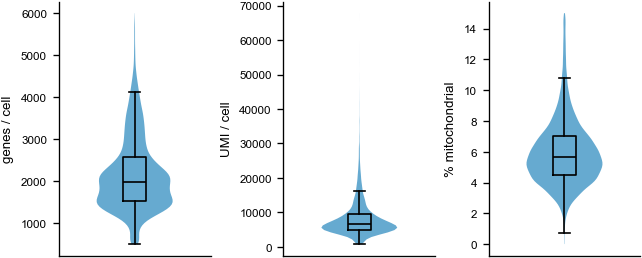

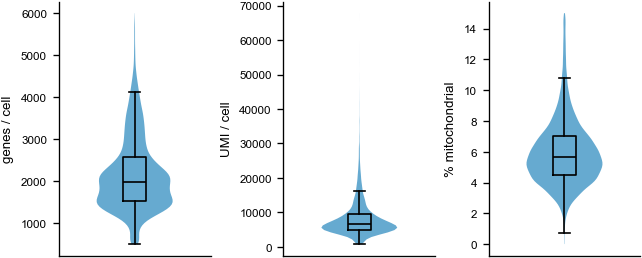

In [4]:
qc = rna.obs[["n_genes_by_counts","total_counts","pct_counts_mito"]].rename(
    columns={"n_genes_by_counts":"genes / cell","total_counts":"UMI / cell",
             "pct_counts_mito":"% mitochondrial"})
fig = P.qc_violins(qc, list(qc.columns)); P.save(fig, f"fig_qc{TAG}"); fig

## 3. Exploration: UMAP, donor batch effect, cell-type label validation

PCA → UMAP on the HVGs, with **Harmony** batch correction over the 8 donors. The
donor UMAPs (before/after) show whether batch correction is warranted.

In [5]:
pp.embed(rna, hvg, run_harmony=True)
CT = rna.obs[LEVEL].astype(str).values
donor = rna.obs[config.DONOR_KEY].astype(str).values

C:\Users\kr3ss\miniforge3\envs\marker-bench\Lib\functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


C:\Users\kr3ss\miniforge3\envs\marker-bench\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-06-10 09:20:01,869 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


C:\Users\kr3ss\miniforge3\envs\marker-bench\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


2026-06-10 09:20:04,216 - harmonypy - INFO - sklearn.KMeans initialization complete.


2026-06-10 09:20:04,279 - harmonypy - INFO - Iteration 1 of 10


2026-06-10 09:20:06,318 - harmonypy - INFO - Iteration 2 of 10


2026-06-10 09:20:08,441 - harmonypy - INFO - Iteration 3 of 10


2026-06-10 09:20:10,558 - harmonypy - INFO - Converged after 3 iterations


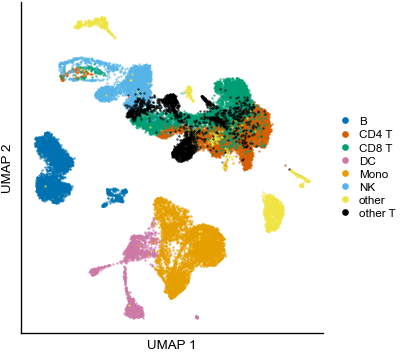

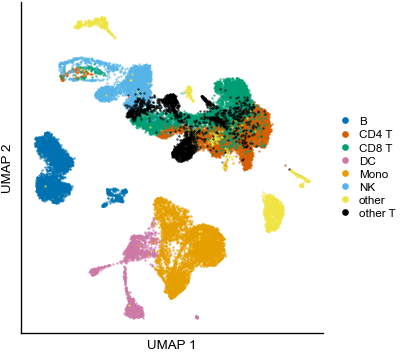

In [6]:
fig,_ = P.embedding_scatter(rna.obsm["X_umap"], CT); P.save(fig,f"fig_umap_celltype{TAG}"); fig

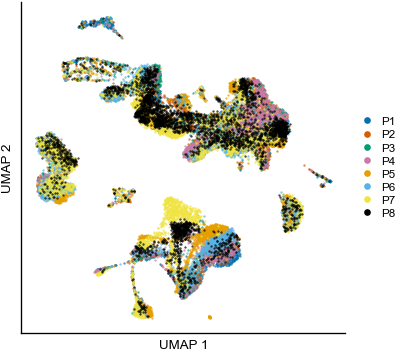

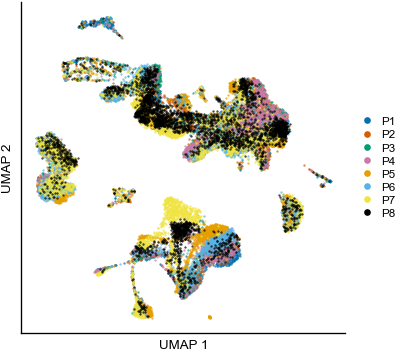

In [7]:
fig,_ = P.embedding_scatter(rna.obsm["X_umap"], donor); P.save(fig,f"fig_umap_donor{TAG}"); fig

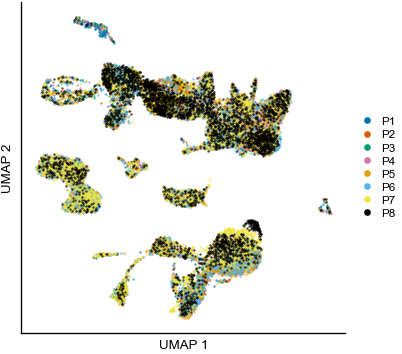

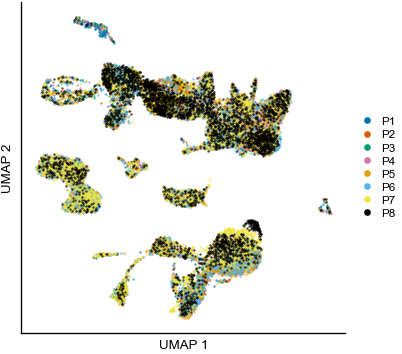

In [8]:
fig,_ = P.embedding_scatter(rna.obsm["X_umap_harmony"], donor); P.save(fig,f"fig_umap_donor_harmony{TAG}"); fig

Cell-type labels validated against the **independent protein channel**: mean
CLR surface-protein level per cell type (z-scored per protein). The block-diagonal
structure (CD3→T, CD19/CD20→B, CD14→monocytes, CD56→NK, …) confirms the WNN labels
agree with direct molecular evidence.

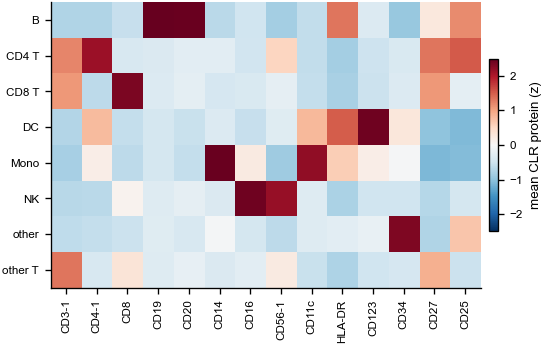

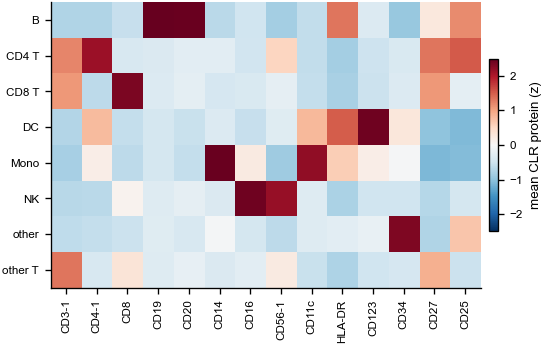

In [9]:
key = [p for p in ["CD3-1","CD4-1","CD8","CD19","CD20","CD14","CD16","CD56-1",
                    "CD11c","HLA-DR","CD123","CD34","CD27","CD25"] if p in adt.var_names]
clr = pd.DataFrame(np.asarray(adt.layers["clr"]), columns=adt.var_names); clr["ct"]=CT
mat = clr.groupby("ct")[key].mean(); matz = (mat-mat.mean())/mat.std()
fig,_ = P.protein_marker_validation_heatmap(matz); P.save(fig, f"fig_adt_validation{TAG}"); fig

## 4. Protein-derived ground truth $D_c$

For each cell type we take the top surface proteins by one-vs-rest Wilcoxon
*score* on CLR-ADT (p-values are uninformative at n≈25k), mapped to encoding
gene(s) by molecular fact only (`src.protein_gene_map`), intersected with the
scored gene universe. This is independent of all four RNA methods.

In [10]:
drivers, details = gt.build_ground_truth(adt, LEVEL, genes_of_interest=genes)
summary = gt.pretty_print_ground_truth(drivers)
summary.to_csv(config.tab_path(f"ground_truth_summary{TAG}"), index=False)
summary

C:\Users\kr3ss\miniforge3\envs\marker-bench\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\kr3ss\miniforge3\envs\marker-bench\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\kr3ss\miniforge3\envs\marker-bench\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\kr3ss\miniforge3\envs\marker-bench\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\kr3ss\miniforge3\envs\marker-bench\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name,

,celltype,n_drivers,drivers
0,CD4 T,13,"CD109, CD2, CD28, CD3D, CD3E, CD3G, CD4, DPP4,..."
1,CD8 T,13,"CD2, CD3D, CD3E, CD3G, CD8A, CD8B, ICOS, KLRK1..."
2,other T,11,"CCR5, CD2, CD28, CD3D, CD3E, CD3G, CD81, CD99,..."
3,B,10,"CCR6, CD19, CD22, CD72, CD79B, HLA-DRA, HLA-DR..."
4,Mono,10,"ANPEP, CD14, CD55, CD93, CLEC12A, ITGAM, ITGAX..."
5,DC,8,"CD63, CD9, CLEC12A, HLA-DRA, HLA-DRB1, ITGA2B,..."
6,NK,8,"B3GAT1, CD244, CD38, FCGR3A, FCGR3B, ITGB2, KL..."
7,other,8,"CCR4, CD9, CLEC1B, ITGA2, ITGA2B, ITGB3, PECAM..."


## 5. The four dependency measures

All operate on the shared matrix `X` and a binary one-vs-rest indicator.

### 5.1 Linear · marginal — Spearman correlation
### 5.2 Linear · conditional — partial correlation (shrinkage)
The empirical gene covariance is ill-conditioned (dropout, collinearity, $p\approx n$),
so a naïve precision matrix is unstable. We use a **Ledoit–Wolf shrinkage**
covariance → precision → point-biserial partial correlation. The eigen-spectrum
below motivates the shrinkage.

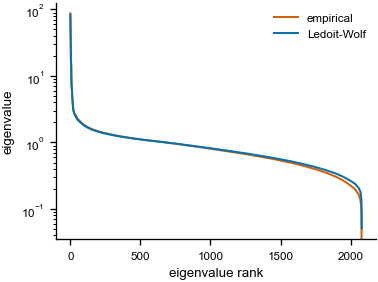

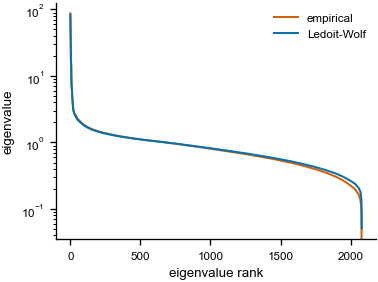

In [11]:
from sklearn.covariance import LedoitWolf
Xs = X - X.mean(0, keepdims=True)
emp = np.linalg.eigvalsh(np.cov(Xs.T))
lw  = np.linalg.eigvalsh(LedoitWolf(assume_centered=True).fit(Xs).covariance_)
fig,_ = P.eigen_spectrum(emp, lw); P.save(fig,f"fig_pcorr_eigenspectrum{TAG}"); fig

### 5.3 Nonlinear · marginal — KSG mutual information
Kraskov–Stögbauer–Grassberger kNN estimator on the rank-transformed expression,
computed one-vs-rest per cell type (parallelised across cell types, estimated on a
fixed 10k-cell subsample for tractability).

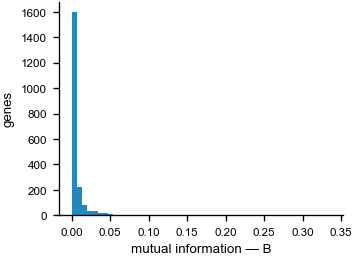

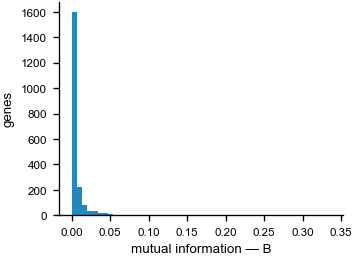

In [12]:
valid = [ct for ct,d in drivers.items()
         if len([g for g in d if g in set(genes)]) >= config.MIN_DRIVERS]
mi_attr = bm.compute_mi_parallel(X, rna.obs[LEVEL].astype(str).values, valid,
                                 n_jobs=-1, seed=config.SEED)
_ex = valid[0]
fig,_ = P.score_hist(mi_attr[_ex], f"mutual information — {_ex}"); P.save(fig,f"fig_mi_hist{TAG}"); fig

### 5.4 Nonlinear · conditional — Integrated Gradients on an MLP
A small classifier with `tanh` hidden layers and a `softmax` output (predictions
on the simplex), trained with cross-entropy + inverse-frequency class weights and
early stopping on validation loss. Integrated Gradients then attributes each class
to the input genes.

**Architecture selection (CV macro-F1 sweep).** Overall accuracy hides
minority-class behaviour, so we select the `tanh`-MLP architecture by 3-fold
cross-validated **macro-F1** (every cell type weighted equally), which targets the
harder, less-abundant lineages. The winning configuration — hidden (512, 256),
dropout 0.4, lr 3e-4, weight decay 1e-4 — is the default in `src.mlp.train_mlp`.

In [13]:
from src import mlp as mlpmod
y = rna.obs[LEVEL].astype(str).values
default_cfg = dict(hidden=(256,128), dropout=0.2, lr=1e-3, weight_decay=1e-5)
tuned_cfg   = dict(hidden=(512,256), dropout=0.4, lr=3e-4, weight_decay=1e-4)

At this granularity (8 classes) the sweep is cheap, so it is run
inline. macro-F1 rises modestly overall but improves the harder classes most.

In [14]:
grid = [default_cfg,
        dict(hidden=(256,128), dropout=0.3, lr=3e-4, weight_decay=1e-4),
        dict(hidden=(512,256), dropout=0.3, lr=3e-4, weight_decay=1e-4),
        dict(hidden=(512,256,128), dropout=0.3, lr=3e-4, weight_decay=1e-4),
        dict(hidden=(256,128), dropout=0.3, lr=1e-4, weight_decay=1e-4),
        tuned_cfg]
sweep = mlpmod.hyperparameter_search(X, y, grid, n_splits=3, seed=config.SEED)
sweep.assign(hidden=sweep.hidden.astype(str)).to_csv(
    config.tab_path(f"mlp_hyperparam_search{TAG}"), index=False)
sweep

[1/6] {'hidden': (256, 128), 'dropout': 0.2, 'lr': 0.001, 'weight_decay': 1e-05} -> acc 0.948 macroF1 0.946


[2/6] {'hidden': (256, 128), 'dropout': 0.3, 'lr': 0.0003, 'weight_decay': 0.0001} -> acc 0.953 macroF1 0.951


[3/6] {'hidden': (512, 256), 'dropout': 0.3, 'lr': 0.0003, 'weight_decay': 0.0001} -> acc 0.952 macroF1 0.950


[4/6] {'hidden': (512, 256, 128), 'dropout': 0.3, 'lr': 0.0003, 'weight_decay': 0.0001} -> acc 0.954 macroF1 0.952


[5/6] {'hidden': (256, 128), 'dropout': 0.3, 'lr': 0.0001, 'weight_decay': 0.0001} -> acc 0.953 macroF1 0.951


[6/6] {'hidden': (512, 256), 'dropout': 0.4, 'lr': 0.0003, 'weight_decay': 0.0001} -> acc 0.954 macroF1 0.952


,hidden,dropout,lr,weight_decay,cv_acc,cv_acc_std,cv_macro_f1,cv_macro_f1_std
0,"(512, 256)",0.4,0.0003,0.00010,0.954073,0.003590,0.952125,0.003259
1,"(512, 256, 128)",0.3,0.0003,0.00010,0.953992,0.001859,0.951535,0.001913
2,"(256, 128)",0.3,0.0003,0.00010,0.953062,0.004034,0.951057,0.004280
3,"(256, 128)",0.3,0.0001,0.00010,0.953184,0.003723,0.950963,0.004104
4,"(512, 256)",0.3,0.0003,0.00010,0.952335,0.003946,0.950407,0.003521
5,"(256, 128)",0.2,0.0010,0.00001,0.947645,0.003874,0.945800,0.003361


default macro-F1 0.946 | tuned macro-F1 0.952


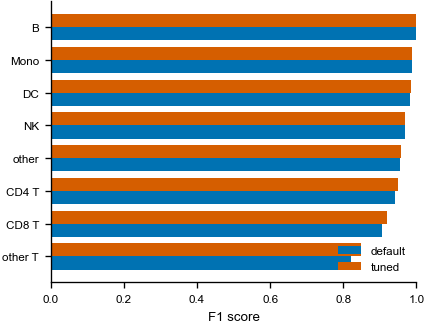

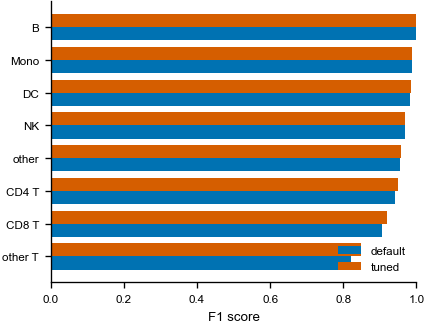

In [15]:
cvd = mlpmod.cross_validate(X, y, n_splits=3, seed=config.SEED, **default_cfg)
cvt = mlpmod.cross_validate(X, y, n_splits=3, seed=config.SEED, **tuned_cfg)
print(f"default macro-F1 {cvd['macro_f1']:.3f} | tuned macro-F1 {cvt['macro_f1']:.3f}")
f1 = {"default": mlpmod.per_class_f1(cvd["y_true"], cvd["y_pred"]),
      "tuned":   mlpmod.per_class_f1(cvt["y_true"], cvt["y_pred"])}
fig,_ = P.per_class_bar(f1); P.save(fig, f"fig_mlp_per_class_f1{TAG}"); fig

The final classifier is trained on all cells with the tuned architecture
(the `src.mlp` default), then Integrated Gradients is computed.

held-out test accuracy: 0.955  (best epoch 2)


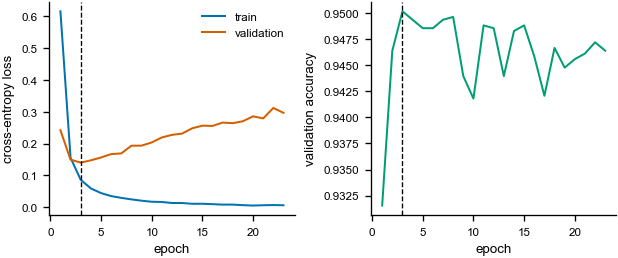

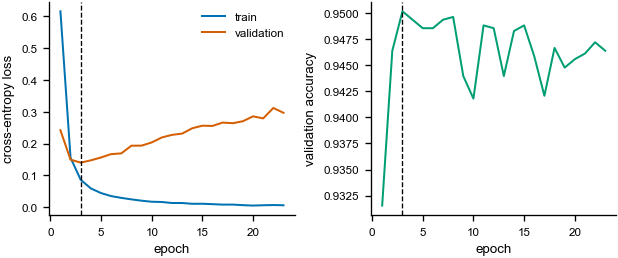

In [16]:
trained = mlpmod.train_mlp(X, y, seed=config.SEED)
print(f"held-out test accuracy: {trained.test_acc:.3f}  (best epoch {trained.history.best_epoch})")
fig,_ = P.mlp_training_curves(trained.history); P.save(fig,f"fig_mlp_training{TAG}"); fig

In [17]:
attr = mlpmod.integrated_gradients(trained, X, y, seed=config.SEED)
classes = list(trained.classes)
ig_attr = {ct: attr[:, classes.index(ct)] for ct in classes}
print("IG attributions:", attr.shape, "(genes × classes)")

IG attributions: (2081, 8) (genes × classes)


UMAP of the MLP's penultimate-layer representation — the nonlinear,
class-discriminative geometry the attributions are read from.

C:\Users\kr3ss\miniforge3\envs\marker-bench\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


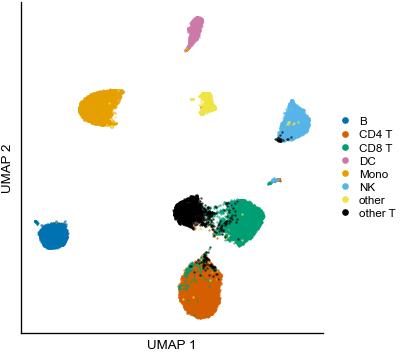

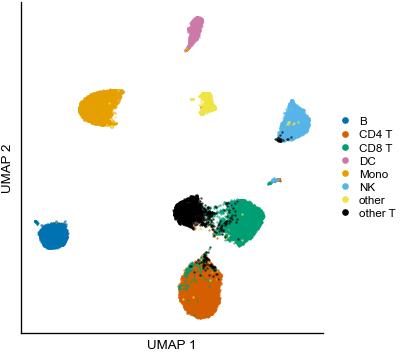

In [18]:
import umap
memb = mlpmod.mlp_embedding(trained, X)
mu = umap.UMAP(random_state=config.SEED).fit_transform(memb)
fig,_ = P.embedding_scatter(mu, CT); P.save(fig,f"fig_mlp_umap{TAG}"); fig

## 6. Benchmark: driver recovery ($\mathrm{AUC_{rel}}$)

$\mathrm{AUC_{rel}}$ is the normalized driver-recovery AUC (≡ Mann–Whitney ROC-AUC
of the per-gene score discriminating drivers from non-drivers): 0.5 = random,
1.0 = perfect, parameter-free, defined on every method's output.

In [19]:
store = {}
res = bm.run_benchmark(X, genes, y, drivers, mi_attr=mi_attr, ig_attr=ig_attr,
                       store_scores=store, seed=config.SEED)
res.to_csv(config.tab_path(f"benchmark_auc_rel{TAG}"), index=False)
res.pivot_table(index="celltype", columns="method", values="auc_rel").round(3)

method,ig_mlp,mi_ksg,partial_corr,spearman
celltype,,,,
B,0.967,0.945,0.577,0.877
CD4 T,0.985,0.890,0.956,0.946
CD8 T,0.851,0.907,0.900,0.992
DC,0.607,0.843,0.472,0.785
Mono,0.962,0.961,0.799,0.966
NK,0.822,0.876,0.767,0.932
other,0.595,0.846,0.576,0.759
other T,0.776,0.894,0.724,0.980


Cumulative recovery curves (x = fraction of all ranked genes), one
panel **per cell type** — recovery is strongly cell-type dependent: on clean
lineages Integrated Gradients can dominate the whole curve, on heterogeneous ones
it trails.

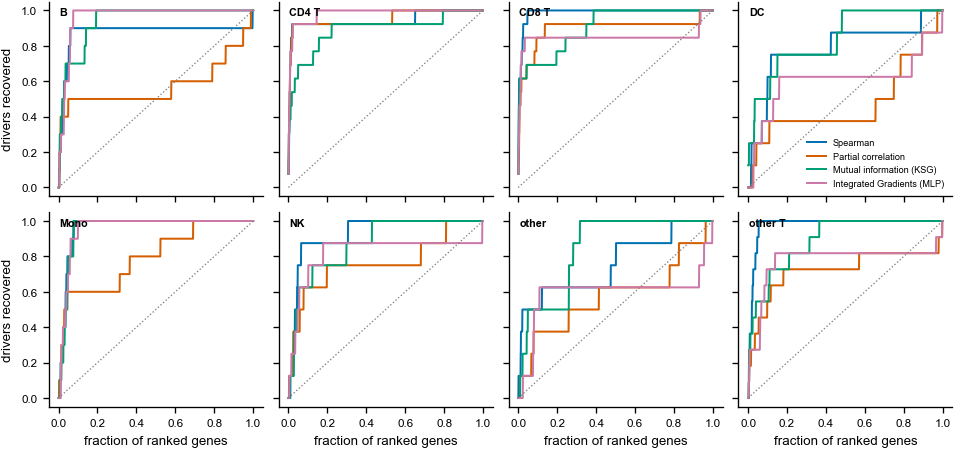

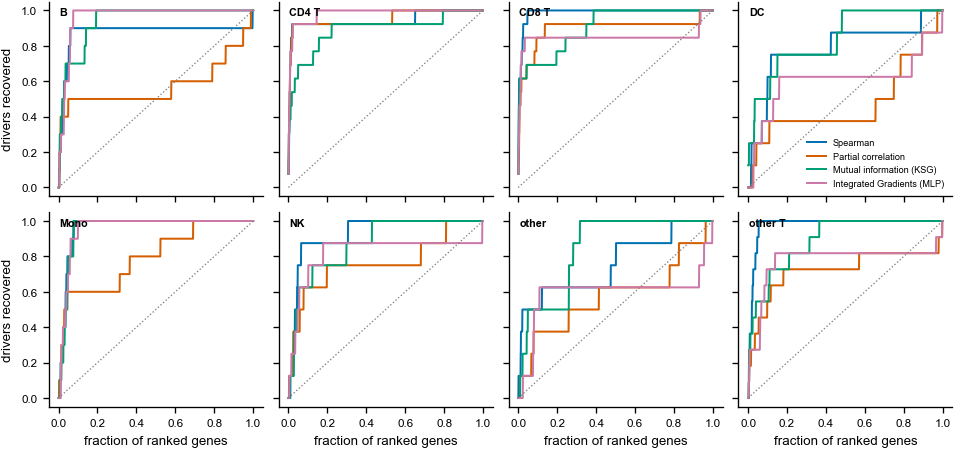

In [20]:
panel = {ct: {m: metric.recovery_curve(store[ct][m], store[ct]["_driver_mask"])
              for m in config.METHODS} for ct in sorted(store)}
fig,_ = P.recovery_curves_panel(panel, ncols=4); P.save(fig,f"fig_recovery_curves{TAG}"); fig

## 7. Statistical comparison

The unit of replication is the **cell type** (paired across methods): a Friedman
omnibus test, then Holm-corrected pairwise Wilcoxon signed-rank tests with
matched-pairs rank-biserial effect sizes.

In [21]:
wide = st.pivot_auc(res)
fried = st.friedman_test(wide)
print(f"Friedman χ² = {fried['statistic']:.2f}, p = {fried['pvalue']:.2e} "
      f"(n = {fried['n_celltypes']} cell types)")
pw = st.pairwise_wilcoxon(wide, method_order=config.METHODS)
pw.to_csv(config.tab_path(f"pairwise_wilcoxon{TAG}"), index=False)
pw

Friedman χ² = 9.45, p = 2.39e-02 (n = 8 cell types)


,method_a,method_b,median_a,median_b,median_diff,statistic,pvalue,rank_biserial,pvalue_holm,significant_0.05
0,spearman,partial_corr,0.938713,0.745368,0.174731,1.0,0.015625,0.944444,0.093750,False
1,spearman,mi_ksg,0.938713,0.891728,0.030236,17.0,0.945312,0.055556,0.945312,False
2,spearman,ig_mlp,0.938713,0.836595,0.125049,5.0,0.078125,0.722222,0.234375,False
3,partial_corr,mi_ksg,0.745368,0.891728,-0.166046,2.0,0.023438,-0.888889,0.117188,False
4,partial_corr,ig_mlp,0.745368,0.836595,-0.053542,3.0,0.039062,-0.833333,0.156250,False
5,mi_ksg,ig_mlp,0.891728,0.836595,0.054968,8.0,0.195312,0.555556,0.390625,False


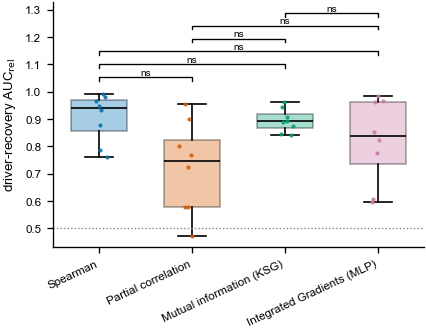

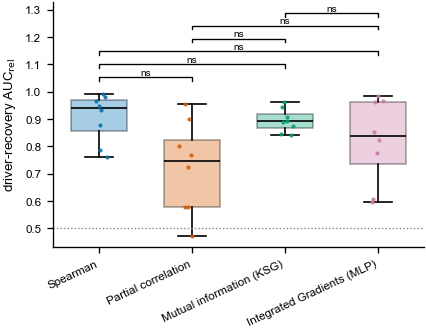

In [22]:
sig = [(r.method_a, r.method_b, "*" if r["significant_0.05"] else "ns")
       for _, r in pw.iterrows()]
fig,_ = P.auc_box(res, config.METHODS, sig_pairs=sig); P.save(fig,f"fig_auc_box{TAG}"); fig

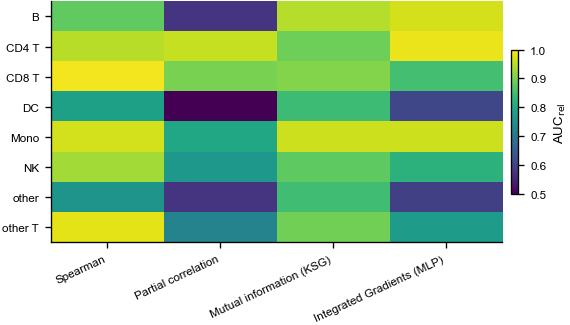

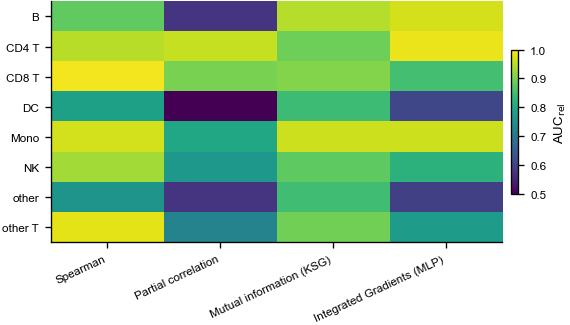

In [23]:
fig,_ = P.auc_heatmap(wide, method_order=config.METHODS); P.save(fig,f"fig_auc_heatmap{TAG}"); fig

### 7.1 Early recovery (recall@k) and sensitivity to heterogeneous categories

$\mathrm{AUC_{rel}}$ integrates the *entire* ranking, but a practitioner only
inspects the top handful of genes. **Recall@k** (fraction of drivers within the
top-k) targets that early regime; the band is a bootstrap over cell types (the
replication unit). Note the axes differ from the per-cell-type curves above: here
x is the **absolute** top-k (a few dozen genes) **averaged over all cell types**,
whereas those curves use the *fraction* of all genes for a *single* type — so a
single-type curve reaching 100% early and a middling cross-type average are
consistent, not contradictory. The whole-curve winner and the early-recovery
winner need not agree.

Zoomed into the **early region** (top ~5% of ranked genes), the same
per-cell-type panels — this is the regime a practitioner actually inspects.

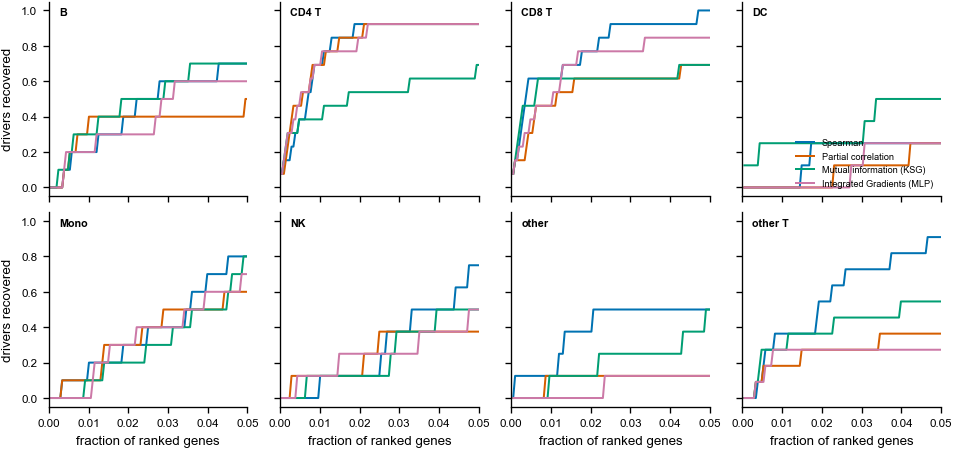

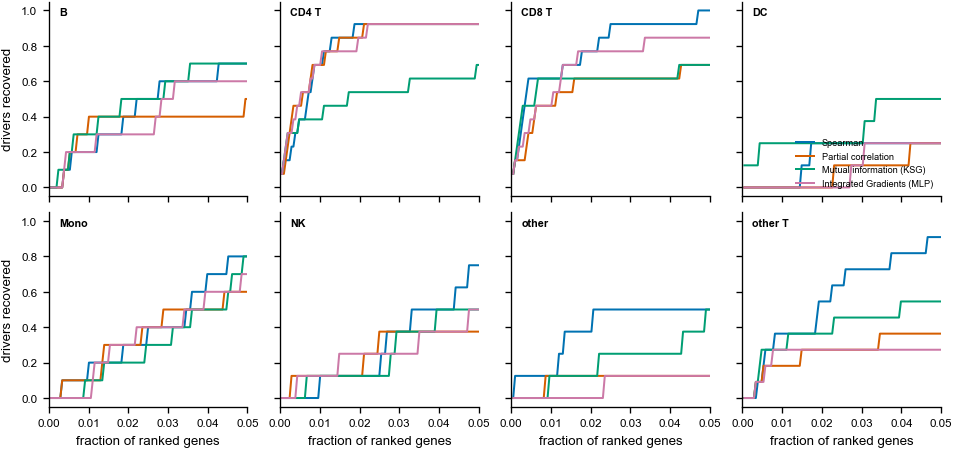

In [24]:
fig,_ = P.recovery_curves_panel(panel, ncols=4, xlim=(0, 0.05))
P.save(fig,f"fig_recovery_early{TAG}"); fig

Heterogeneous grab-bag categories (e.g. `other`, `other T`) have weak,
ambiguous protein-derived ground truth and depress recovery for *all* methods —
Integrated Gradients most. The table below (mean AUC_rel with vs without them) is a
transparency check showing how much the aggregate understates the model-based
method on cleanly-defined cell types.

In [25]:
hetero = [c for c in res.celltype.unique() if "other" in c.lower()]
print("heterogeneous categories at this granularity:", hetero or "none")
sens = pd.DataFrame({"mean_auc_all": res.groupby("method").auc_rel.mean()})
if hetero:
    sens["mean_auc_excl_other"] = res[~res.celltype.isin(hetero)].groupby("method").auc_rel.mean()
sens.round(3).loc[config.METHODS]

heterogeneous categories at this granularity: ['other', 'other T']


,mean_auc_all,mean_auc_excl_other
method,,
spearman,0.904,0.916
partial_corr,0.721,0.745
mi_ksg,0.895,0.904
ig_mlp,0.821,0.866


## 8. Cross-method comparison (gene level)

Pooling every (gene, cell type) score (z-scored within cell type), how do the four
measures relate, and where do the protein-confirmed drivers sit? The pairwise
scatter matrix and the 3-D view (partial correlation × MI × IG) make the
agreement/disagreement structure explicit; protein-derived drivers are
highlighted.

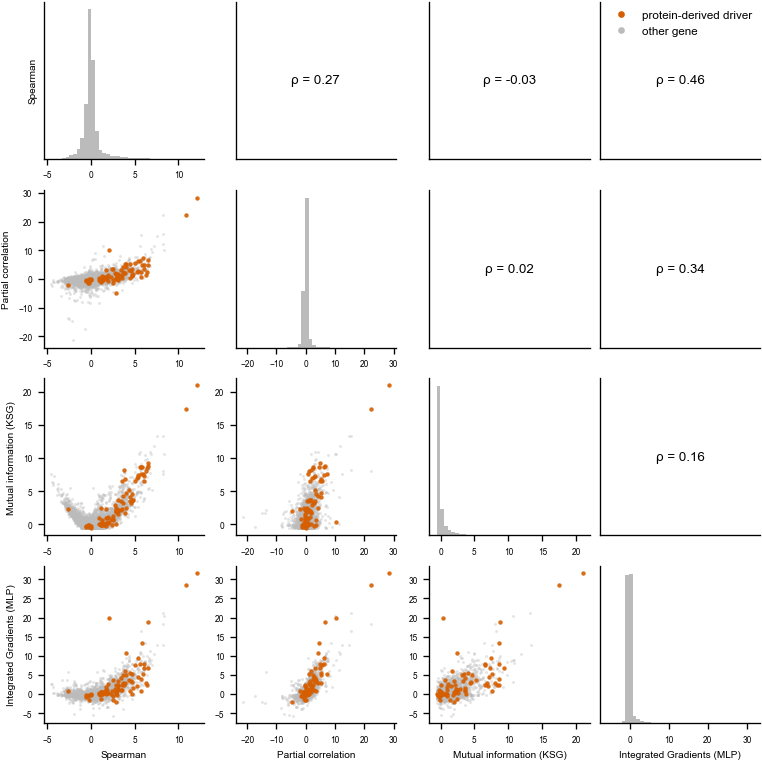

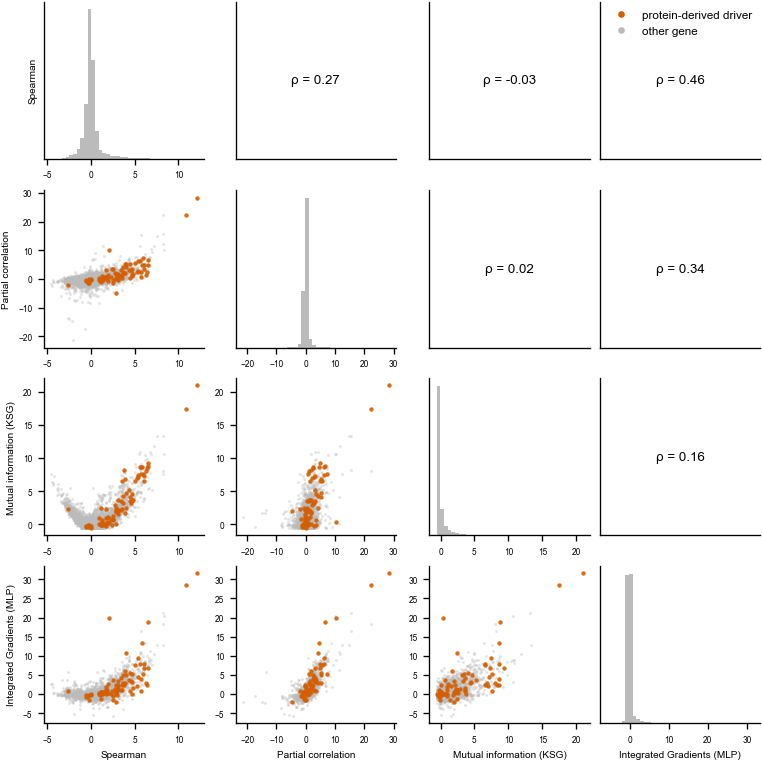

In [26]:
long = bm.scores_to_long(store, genes)
long.to_parquet(config.PROCESSED_DATA_DIR_PATH / f"scores_long{TAG}.parquet")
fig,_ = P.pairwise_scatter_matrix(long, config.METHODS); P.save(fig,f"fig_pairwise_scatter{TAG}"); fig

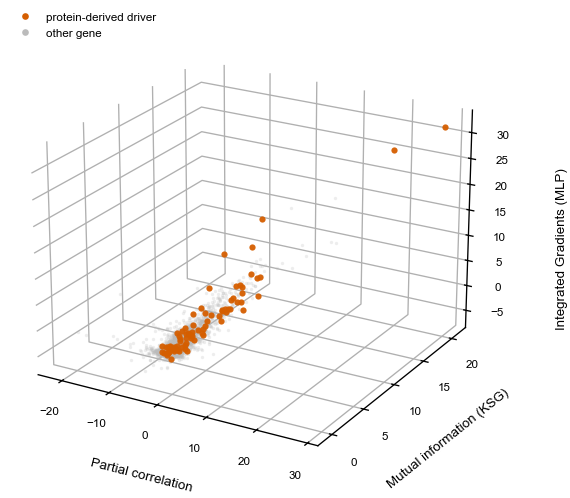

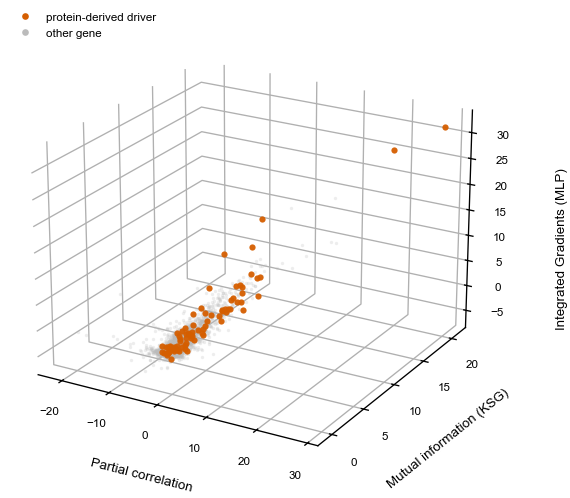

In [27]:
fig,_ = P.scatter3d(long, "partial_corr", "mi_ksg", "ig_mlp"); P.save(fig,f"fig_scatter3d{TAG}", tight=False); fig

## 9. Stability and robustness

Descriptive stability bands (not inference): **bootstrap over cells** for the
closed-form methods, and **MLP-seed variation** for Integrated Gradients. At this
granularity the bootstrap is cheap, so it is computed inline.

In [28]:
boot = bm.bootstrap_over_cells(X, genes, y, drivers, n_boot=5,
                              boot_cells=3000, seed=config.SEED)
boot.to_csv(config.tab_path(f"stability_bootstrap{TAG}"))
boot.round(3)

,mean,std,ci_lo,ci_hi
method,,,,
mi_ksg,0.865,0.006,0.858,0.873
partial_corr,0.724,0.019,0.701,0.749
spearman,0.899,0.008,0.892,0.911


In [29]:
seedf = bm.seed_stability_ig(X, genes, y, drivers, mi_attr,
                            seeds=(0,1,2), seed=config.SEED)
seedf.to_csv(config.tab_path(f"stability_seed{TAG}"), index=False)
seedf.round(3)

,seed,mean_auc_rel,test_acc
0,0,0.821,0.955
1,1,0.822,0.957
2,2,0.819,0.952


## 10. Summary

The figures and tables above decompose marker-gene identification along the
linear/nonlinear and marginal/conditional axes against an independent,
protein-derived ground truth, at this annotation granularity. Comparing against
the other granularity's notebook indicates whether the conclusion (which
statistical assumption changes the recovered markers) is robust to how finely cell
types are defined. See the report for interpretation.